# TS-SatFire -- UNet3D v4 -- Inference and Analysis

This notebook evaluates the trained UNet3D v4 model on the held-out test set
(24 wildfire events from 2021) and produces a comprehensive statistical analysis.

## Required inputs
Add the following Kaggle datasets as inputs before running:
1. `z789456sx/ts-satfire` -- the raw dataset
2. Your uploaded weights dataset containing:
   - `unet3d_v4_ba_best.pt`
   - `norm_stats_v4.npz`
   - `run_meta_v4.json`
   - `history_v4.json`

## Outputs produced
- `test_results_v4.json` -- per-fire and overall test metrics
- `per_fire_results_v4.csv` -- per-fire F1, IoU, TP, FP, FN
- `model_analysis_v4.txt` -- full parameter count and layer breakdown
- `training_curves_v4_final.png` -- training history with test result marked
- `f1_distribution_v4.png` -- F1 distribution and FP/FN analysis
- `benchmark_comparison_v4.png` -- comparison against all paper baselines
- `visual_predictions_v4.png` -- random sample of test fire predictions
- `unet3d_v4_results.zip` -- all of the above bundled

In [1]:
import os
import sys
import glob
import json
import math
import random
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i} : {torch.cuda.get_device_name(i)}')

PyTorch : 2.9.0+cu126
CUDA    : True
  GPU 0 : Tesla T4
  GPU 1 : Tesla T4


## Configuration

In [2]:
# Raw dataset path
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Locate weights -- search common Kaggle mount patterns
WEIGHTS_DIR = None
search_roots = [
    '/kaggle/input/unet3d-v4-weights',
    '/kaggle/input/unet3dv4weights',
    '/kaggle/input/unet3d-v4',
]
for sr in search_roots:
    if os.path.isdir(sr):
        WEIGHTS_DIR = sr
        break
if WEIGHTS_DIR is None:
    # Fall back: search all /kaggle/input subdirs for the weights file
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'unet3d_v4_ba_best.pt' in files:
            WEIGHTS_DIR = root
            break
if WEIGHTS_DIR is None:
    raise RuntimeError('Could not find weights directory. '
                       'Add your weights dataset as input to this notebook.')
print(f'Weights directory : {WEIGHTS_DIR}')

CKPT_PATH  = os.path.join(WEIGHTS_DIR, 'unet3d_v4_ba_best.pt')
STATS_PATH = os.path.join(WEIGHTS_DIR, 'norm_stats_v4.npz')
META_PATH  = os.path.join(WEIGHTS_DIR, 'run_meta_v4.json')
HIST_PATH  = os.path.join(WEIGHTS_DIR, 'history_v4.json')

for p in [CKPT_PATH, STATS_PATH, META_PATH]:
    print(f'  {"OK" if os.path.exists(p) else "MISSING":6} {p}')

# Load run metadata
with open(META_PATH) as f:
    meta = json.load(f)

TIME_STEPS    = meta['TIME_STEPS']
CHANS_PER_STEP = meta['CHANS_PER_STEP']
PATCH_SIZE    = meta['PATCH_SIZE']
BASE_CH       = meta['BASE_CH']
INFER_THRESHOLD = meta['INFER_THRESHOLD']
SEED          = meta['SEED']
VAL_INTERVAL  = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice          : {device}')
print(f'TIME_STEPS      : {TIME_STEPS}')
print(f'CHANS_PER_STEP  : {CHANS_PER_STEP}')
print(f'BASE_CH         : {BASE_CH}')
print(f'INFER_THRESHOLD : {INFER_THRESHOLD}')

Weights directory : /kaggle/input/datasets/con1los/unet3d-v4-weights
  OK     /kaggle/input/datasets/con1los/unet3d-v4-weights/unet3d_v4_ba_best.pt
  OK     /kaggle/input/datasets/con1los/unet3d-v4-weights/norm_stats_v4.npz
  OK     /kaggle/input/datasets/con1los/unet3d-v4-weights/run_meta_v4.json

Device          : cuda
TIME_STEPS      : 2
CHANS_PER_STEP  : 26
BASE_CH         : 32
INFER_THRESHOLD : 0.5


## Dataset split reconstruction

Reconstruct the exact same train/val/test split from run_meta_v4.json
so inference uses the same held-out test fires as training did.

In [3]:
all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])

REQUIRED = {'VIIRS_Day', 'VIIRS_Night', 'FirePred'}
fire_dirs = []
for d in all_dirs:
    if REQUIRED.issubset(set(os.listdir(d))):
        fire_dirs.append(d)

def fp_chan_count(fd):
    files = sorted(glob.glob(os.path.join(fd, 'FirePred', '*.tif')))
    if not files: return -1
    with rasterio.open(files[0]) as src: return src.count

fire_dirs = [fd for fd in fire_dirs if fp_chan_count(fd) == 19]

# Reconstruct split from saved fire IDs
test_ids  = set(meta['test_fire_ids'])
val_ids   = set(meta['val_fire_ids'])
train_ids = set(meta['train_fire_ids'])

test_fires  = [fd for fd in fire_dirs if os.path.basename(fd) in test_ids]
val_fires   = [fd for fd in fire_dirs if os.path.basename(fd) in val_ids]
train_fires = [fd for fd in fire_dirs if os.path.basename(fd) in train_ids]

print(f'Usable fires    : {len(fire_dirs)}')
print(f'Train fires     : {len(train_fires)}')
print(f'Val fires       : {len(val_fires)}')
print(f'Test fires      : {len(test_fires)}  (2021 holdout)')

missing = test_ids - {os.path.basename(fd) for fd in test_fires}
if missing:
    print(f'WARNING: {len(missing)} test fires not found on disk: {missing}')

Usable fires    : 173
Train fires     : 127
Val fires       : 22
Test fires      : 24  (2021 holdout)


## Normalisation statistics

In [4]:
data       = np.load(STATS_PATH)
CHAN_MEANS  = data['means']
CHAN_STDS   = data['stds']
CLIP_LO     = data['clip_lo']
CLIP_HI     = data['clip_hi']
print(f'Loaded normalisation stats from {STATS_PATH}')
print(f'Means range : [{CHAN_MEANS.min():.3f}, {CHAN_MEANS.max():.3f}]')
print(f'Stds  range : [{CHAN_STDS.min():.3f}, {CHAN_STDS.max():.3f}]')

Loaded normalisation stats from /kaggle/input/datasets/con1los/unet3d-v4-weights/norm_stats_v4.npz
Means range : [-0.123, 4260.868]
Stds  range : [0.002, 2406.180]


## Dataset class

In [5]:
class TSSatFireDataset(Dataset):

    def __init__(self, fire_dirs, time_steps=TIME_STEPS,
                 interval=1, patch_size=None,
                 means=None, stds=None,
                 clip_lo=None, clip_hi=None):
        self.T          = time_steps
        self.interval   = interval
        self.patch_size = patch_size
        self.means      = means
        self.stds       = stds
        self.clip_lo    = clip_lo
        self.clip_hi    = clip_hi
        self.samples    = []
        self._build_index(fire_dirs)

    def _build_index(self, fire_dirs):
        for fd in fire_dirs:
            day_files = sorted(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
            if len(day_files) < self.T:
                continue
            n = len(day_files)
            start = 0
            while start + self.T <= n:
                self.samples.append({
                    'fire_dir'  : fd,
                    'day_files' : day_files,
                    'start'     : start,
                    'end'       : start + self.T - 1,
                })
                start += self.interval
        print(f'Dataset: {len(self.samples)} samples (T={self.T}, interval={self.interval})')

    @staticmethod
    def _date(path):
        return os.path.basename(path).replace('_VIIRS_Day.tif', '')

    def _load_timestep(self, fd, day_path, H, W):
        date_str   = self._date(day_path)
        night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
        fp_path    = os.path.join(fd, 'FirePred',    f'{date_str}_FirePred.tif')
        with rasterio.open(day_path) as src:
            day_arr = src.read().astype(np.float32)
        spectral = day_arr[:6, :H, :W]
        if os.path.exists(night_path):
            with rasterio.open(night_path) as src:
                night = src.read().astype(np.float32)[:2, :H, :W]
        else:
            night = np.full((2, H, W), np.nan, np.float32)
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                fp = src.read().astype(np.float32)
            if fp.shape[1] != H or fp.shape[2] != W:
                fp = F.interpolate(torch.from_numpy(fp).unsqueeze(0),
                                   size=(H, W), mode='nearest').squeeze(0).numpy()
            aux = np.concatenate([fp[:2], fp[3:]], axis=0)
        else:
            aux = np.zeros((18, H, W), np.float32)
        return np.concatenate([spectral, night, aux], axis=0)

    def _load_label(self, fd, day_path, H, W):
        date_str = self._date(day_path)
        fp_path  = os.path.join(fd, 'FirePred', f'{date_str}_FirePred.tif')
        if os.path.exists(fp_path):
            with rasterio.open(fp_path) as src:
                ch2 = src.read(3).astype(np.float32)
            if ch2.shape[0] != H or ch2.shape[1] != W:
                ch2 = F.interpolate(
                    torch.from_numpy(ch2).unsqueeze(0).unsqueeze(0),
                    size=(H, W), mode='nearest').squeeze().numpy()
            return (ch2 > 0).astype(np.float32)
        return np.zeros((H, W), np.float32)

    def _thermal_cummax(self, fd, all_day_files, win_end, H, W):
        history = []
        for i in range(win_end + 1):
            dp       = all_day_files[i]
            date_str = self._date(dp)
            np_path  = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
            with rasterio.open(dp) as src:
                i4d = src.read(4).astype(np.float32)[:H, :W]
                i5d = src.read(5).astype(np.float32)[:H, :W]
            if os.path.exists(np_path):
                with rasterio.open(np_path) as src:
                    i4n = src.read(1).astype(np.float32)[:H, :W]
                    i5n = src.read(2).astype(np.float32)[:H, :W]
            else:
                i4n = np.full((H, W), np.nan, np.float32)
                i5n = np.full((H, W), np.nan, np.float32)
            history.append(np.stack([i4d, i5d, i4n, i5n]))
        return history

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s         = self.samples[idx]
        fd        = s['fire_dir']
        all_files = s['day_files']
        win_start = s['start']
        win_end   = s['end']
        win_files = all_files[win_start : win_end + 1]
        shapes = []
        for dp in win_files:
            with rasterio.open(dp) as src:
                shapes.append((src.height, src.width))
        H = min(sh[0] for sh in shapes)
        W = min(sh[1] for sh in shapes)
        frames  = [self._load_timestep(fd, dp, H, W) for dp in win_files]
        history = self._thermal_cummax(fd, all_files, win_end, H, W)
        for t in range(self.T):
            gd  = win_start + t
            cmx = np.nanmax(np.stack(history[:gd + 1]), axis=0)
            frames[t][3] = cmx[0]
            frames[t][4] = cmx[1]
            frames[t][6] = cmx[2]
            frames[t][7] = cmx[3]
        stack = np.stack(frames, axis=0)
        if self.clip_lo is not None:
            stack = np.clip(stack,
                            self.clip_lo[None, :, None, None],
                            self.clip_hi[None, :, None, None])
        if self.means is not None:
            stack = (stack - self.means[None, :, None, None]) / \
                     self.stds[ None, :, None, None]
        stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
        label = self._load_label(fd, win_files[-1], H, W)
        if self.patch_size and H > self.patch_size and W > self.patch_size:
            r0 = (H - self.patch_size) // 2
            c0 = (W - self.patch_size) // 2
            p  = self.patch_size
            stack = stack[:, :, r0:r0+p, c0:c0+p]
            label = label[r0:r0+p, c0:c0+p]
        x = torch.from_numpy(stack.transpose(1, 0, 2, 3).copy()).float()
        y = torch.from_numpy(label).long()
        return x, y

print('TSSatFireDataset defined.')

TSSatFireDataset defined.


## Model definition

In [6]:
class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=CHANS_PER_STEP, base_ch=BASE_CH, n_classes=2):
        super().__init__()
        b = base_ch
        self.enc1 = DoubleConv3D(in_channels, b)
        self.enc2 = DoubleConv3D(b,   b*2)
        self.enc3 = DoubleConv3D(b*2, b*4, dropout=0.1)
        self.enc4 = DoubleConv3D(b*4, b*8, dropout=0.1)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool2 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool3 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.pool4 = nn.MaxPool3d(kernel_size=(1, 2, 2))
        self.bottleneck = DoubleConv3D(b*8, b*16, dropout=0.1)
        self.up4  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec4 = DoubleConv3D(b*16 + b*8, b*8)
        self.up3  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec3 = DoubleConv3D(b*8  + b*4, b*4)
        self.up2  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec2 = DoubleConv3D(b*4  + b*2, b*2)
        self.up1  = nn.Upsample(scale_factor=(1, 2, 2), mode='trilinear', align_corners=False)
        self.dec1 = DoubleConv3D(b*2  + b,   b)
        self.head = nn.Conv3d(b, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        bn = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        logits = self.head(d1)
        return logits[:, :, -1, :, :]


model = UNet3D(in_channels=CHANS_PER_STEP, base_ch=BASE_CH, n_classes=2).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f'Loaded checkpoint from {CKPT_PATH}')

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {n_params:,}  ({n_params/1e6:.2f}M)')
print(f'Trainable parameters : {n_train:,}  ({n_train/1e6:.2f}M)')

Loaded checkpoint from /kaggle/input/datasets/con1los/unet3d-v4-weights/unet3d_v4_ba_best.pt
Total parameters     : 23,556,866  (23.56M)
Trainable parameters : 23,556,866  (23.56M)


## Detailed model analysis

Layer-by-layer parameter breakdown saved to `model_analysis_v4.txt`.

In [7]:
def get_model_analysis(model):
    lines = []
    lines.append('=' * 80)
    lines.append('UNet3D v4 -- Model Architecture Analysis')
    lines.append('=' * 80)
    lines.append(f'Input shape  : (N, {CHANS_PER_STEP}, {TIME_STEPS}, H, W)')
    lines.append(f'Output shape : (N, 2, H, W)  -- 2-class logits for last timestep')
    lines.append(f'Base channels: {BASE_CH}')
    lines.append('')

    # Layer-by-layer breakdown
    lines.append(f'{"Layer":<45} {"Type":<20} {"Params":>12} {"Shape"}')
    lines.append('-' * 100)

    total = 0
    section_totals = {}
    current_section = ''

    for name, module in model.named_modules():
        if not list(module.children()):  # leaf modules only
            params = sum(p.numel() for p in module.parameters())
            if params == 0:
                continue
            # Determine section from name prefix
            section = name.split('.')[0] if '.' in name else name
            if section != current_section:
                if current_section and current_section in section_totals:
                    lines.append(f'  >> {current_section} subtotal: {section_totals[current_section]:,}')
                    lines.append('')
                current_section = section
                section_totals[section] = 0
            section_totals[section] = section_totals.get(section, 0) + params

            # Get weight shape if available
            shape_str = ''
            for pname, p in module.named_parameters():
                if pname == 'weight':
                    shape_str = str(tuple(p.shape))
                    break

            mtype = type(module).__name__
            lines.append(f'{name:<45} {mtype:<20} {params:>12,} {shape_str}')
            total += params

    if current_section and current_section in section_totals:
        lines.append(f'  >> {current_section} subtotal: {section_totals[current_section]:,}')

    lines.append('')
    lines.append('=' * 80)
    lines.append(f'TOTAL PARAMETERS : {total:,}  ({total/1e6:.3f}M)')

    # Section summary
    lines.append('')
    lines.append('Section summary:')
    lines.append(f'{"Section":<20} {"Params":>12} {"% of total":>12}')
    lines.append('-' * 46)
    for sec, cnt in section_totals.items():
        lines.append(f'{sec:<20} {cnt:>12,} {100*cnt/total:>11.1f}%')

    # Memory estimate
    lines.append('')
    lines.append('Memory estimate (float32):')
    mem_mb = total * 4 / 1024**2
    lines.append(f'  Weights : {mem_mb:.1f} MB')
    # Activation memory for a 128x128 patch, T=2
    b = BASE_CH
    act_elements = (
        b   * 2 * 128 * 128 +   # enc1
        b*2 * 2 * 64  * 64  +   # enc2
        b*4 * 2 * 32  * 32  +   # enc3
        b*8 * 2 * 16  * 16  +   # enc4
        b*16* 2 * 8   * 8       # bottleneck
    ) * 2  # x2 for decoder mirrors
    act_mb = act_elements * 4 / 1024**2
    lines.append(f'  Activations (batch=1, 128x128): ~{act_mb:.1f} MB')
    lines.append('=' * 80)

    return '\n'.join(lines)


analysis_text = get_model_analysis(model)
print(analysis_text)

analysis_path = os.path.join(OUTPUT_DIR, 'model_analysis_v4.txt')
with open(analysis_path, 'w') as f:
    f.write(analysis_text)
print(f'\nSaved to {analysis_path}')

UNet3D v4 -- Model Architecture Analysis
Input shape  : (N, 26, 2, H, W)
Output shape : (N, 2, H, W)  -- 2-class logits for last timestep
Base channels: 32

Layer                                         Type                       Params Shape
----------------------------------------------------------------------------------------------------
enc1.block.0                                  Conv3d                     22,464 (32, 26, 3, 3, 3)
enc1.block.1                                  BatchNorm3d                    64 (32,)
enc1.block.3                                  Conv3d                     27,648 (32, 32, 3, 3, 3)
enc1.block.4                                  BatchNorm3d                    64 (32,)
  >> enc1 subtotal: 50,240

enc2.block.0                                  Conv3d                     55,296 (64, 32, 3, 3, 3)
enc2.block.1                                  BatchNorm3d                   128 (64,)
enc2.block.3                                  Conv3d                    110,

## Padding utility

In [8]:
def pad_to_multiple(x, multiple=16):
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W

print('pad_to_multiple defined.')

pad_to_multiple defined.


## Test set inference

Run inference on all 156 test samples across 24 fires.
Results are accumulated both globally and per-fire.

In [9]:
test_ds = TSSatFireDataset(
    fire_dirs  = test_fires,
    time_steps = TIME_STEPS,
    interval   = VAL_INTERVAL,
    patch_size = None,
    means      = CHAN_MEANS,
    stds       = CHAN_STDS,
    clip_lo    = CLIP_LO,
    clip_hi    = CLIP_HI,
)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False,
                         num_workers=0, pin_memory=True)
print(f'Test samples : {len(test_ds)}')

# Global accumulators
global_tp = global_fp = global_fn = 0
sample_f1s   = []
sample_fire_ids = []

# Per-fire accumulators
fire_stats = {}  # fid -> {tp, fp, fn, n_days}

use_amp = torch.cuda.is_available()

model.eval()
with torch.no_grad():
    for idx, (x, y) in enumerate(tqdm(test_loader, desc='Test inference')):
        fid = os.path.basename(test_ds.samples[idx]['fire_dir'])
        x   = x.to(device, non_blocking=True)
        y   = y.to(device, non_blocking=True)

        xp, H_orig, W_orig = pad_to_multiple(x)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(xp)
        logits = logits[:, :, :H_orig, :W_orig]

        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > INFER_THRESHOLD).long()
        tgt   = y.long()

        tp = int((preds * tgt).sum())
        fp = int((preds * (1 - tgt)).sum())
        fn = int(((1 - preds) * tgt).sum())

        global_tp += tp
        global_fp += fp
        global_fn += fn

        denom = 2*tp + fp + fn
        sample_f1s.append(2*tp / denom if denom > 0 else 0.0)
        sample_fire_ids.append(fid)

        if fid not in fire_stats:
            fire_stats[fid] = {'tp': 0, 'fp': 0, 'fn': 0, 'n_days': 0}
        fire_stats[fid]['tp'] += tp
        fire_stats[fid]['fp'] += fp
        fire_stats[fid]['fn'] += fn
        fire_stats[fid]['n_days'] += 1

# Global metrics
overall_f1  = 2*global_tp / (2*global_tp + global_fp + global_fn)
overall_iou = global_tp / (global_tp + global_fp + global_fn)
mean_f1     = float(np.mean(sample_f1s))

print(f'\nTest Set Results')
print('=' * 40)
print(f'Overall F1  : {overall_f1:.4f}')
print(f'Overall IoU : {overall_iou:.4f}')
print(f'Mean F1     : {mean_f1:.4f}')
print(f'Total TP    : {global_tp:,}')
print(f'Total FP    : {global_fp:,}')
print(f'Total FN    : {global_fn:,}')
print(f'FP/FN ratio : {global_fp/(global_fn+1e-6):.2f}')

Dataset: 220 samples (T=2, interval=4)
Test samples : 220


Test inference:   0%|          | 0/220 [00:00<?, ?it/s]


Test Set Results
Overall F1  : 0.8994
Overall IoU : 0.8173
Mean F1     : 0.4441
Total TP    : 11,667,802
Total FP    : 1,634,624
Total FN    : 974,458
FP/FN ratio : 1.68


## Per-fire results table

In [10]:
records = []
for fid, s in fire_stats.items():
    tp, fp, fn = s['tp'], s['fp'], s['fn']
    f1  = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
    records.append({
        'fire_id': fid,
        'F1'     : round(f1, 4),
        'IoU'    : round(iou, 4),
        'TP'     : tp,
        'FP'     : fp,
        'FN'     : fn,
        'n_days' : s['n_days'],
    })

df_fire = pd.DataFrame(records).sort_values('F1', ascending=False).reset_index(drop=True)
csv_path = os.path.join(OUTPUT_DIR, 'per_fire_results_v4.csv')
df_fire.to_csv(csv_path, index=False)

print(df_fire.to_string(index=False))
print(f'\nFires with F1 > 0.8 : {(df_fire.F1 > 0.8).sum()} / {len(df_fire)}')
print(f'Fires with F1 > 0.6 : {(df_fire.F1 > 0.6).sum()} / {len(df_fire)}')
print(f'Fires with F1 = 0.0 : {(df_fire.F1 == 0.0).sum()} / {len(df_fire)}')
print(f'Median F1           : {df_fire.F1.median():.4f}')
print(f'Std F1              : {df_fire.F1.std():.4f}')

# Save full results JSON
results = {
    'overall_F1' : overall_f1,
    'overall_IoU': overall_iou,
    'mean_F1'    : mean_f1,
    'median_F1'  : float(df_fire.F1.median()),
    'std_F1'     : float(df_fire.F1.std()),
    'total_TP'   : global_tp,
    'total_FP'   : global_fp,
    'total_FN'   : global_fn,
    'fp_fn_ratio': global_fp / (global_fn + 1e-6),
    'n_test_fires': len(df_fire),
    'n_test_samples': len(test_ds),
    'per_fire'   : df_fire.to_dict('records'),
}
with open(os.path.join(OUTPUT_DIR, 'test_results_v4.json'), 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nSaved test_results_v4.json')

                      fire_id     F1    IoU      TP     FP     FN  n_days
US_2021_NM3340210587120210426 0.9963 0.9927  352668     34   2553       3
US_2021_CA3568711855020210818 0.9858 0.9721  234172   3262   3467       6
US_2021_WA4828511853120210713 0.9427 0.8915  971776  67128  51093      17
US_2021_MT4568311385420210708 0.9400 0.8868 2385754 175366 129212      19
US_2021_AZ3368910927620210616 0.9263 0.8627  753522  21781  98103       6
US_2021_WA4879111827120210805 0.9251 0.8606  495884  35089  45201       7
US_2021_ID4762711608320210708 0.9208 0.8532 1167398  78648 122191      15
US_2021_NM3323810847220210520 0.9188 0.8497  327035  20016  37810      10
US_2021_WA4856812048820210708 0.9160 0.8449  237844  23188  20461       9
US_2021_AZ3345510938920210616 0.9145 0.8424  525742  12035  86311       5
US_2021_WA4877811903420210803 0.9139 0.8415  360091  17191  50630      12
US_2021_ID4453211532920210810 0.9000 0.8182  508683  91072  21925      15
US_2021_NM3676810505920211120 0.8908 0

## Statistical analysis plots

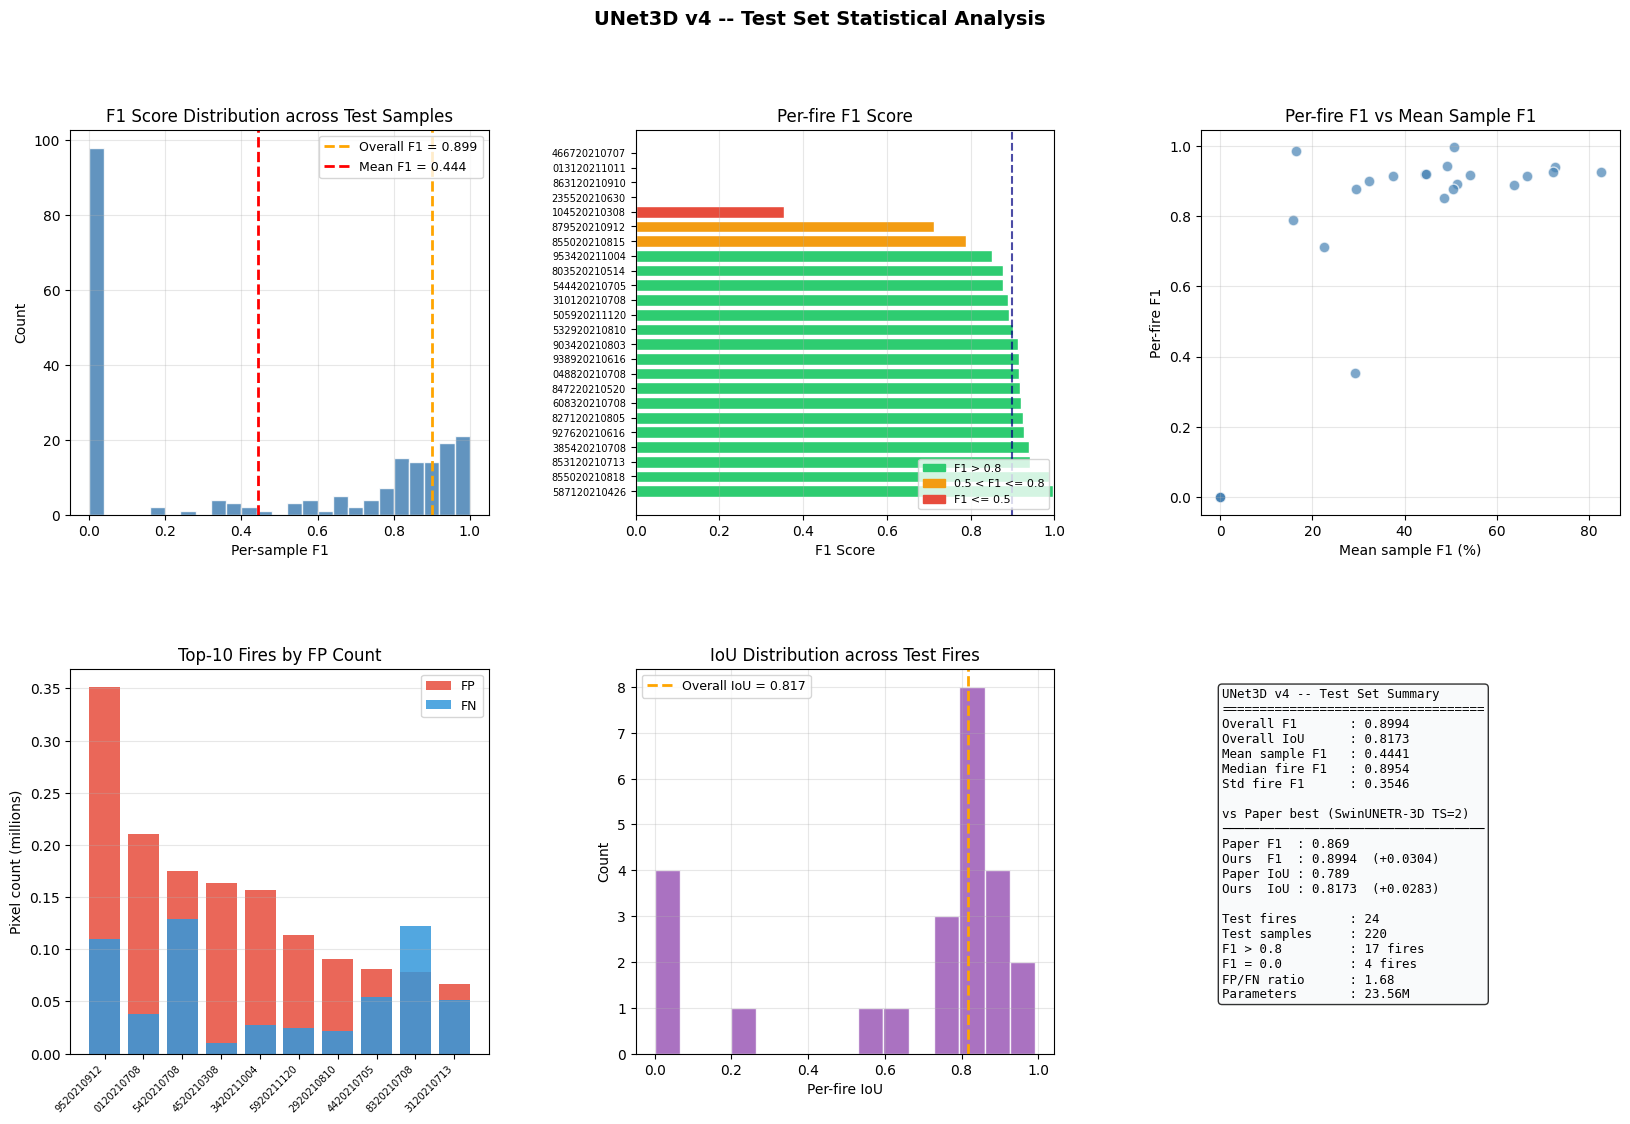

Saved /kaggle/working/f1_distribution_v4.png


In [11]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. F1 distribution histogram
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(sample_f1s, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(overall_f1, color='orange', lw=2, ls='--', label=f'Overall F1 = {overall_f1:.3f}')
ax1.axvline(mean_f1,    color='red',    lw=2, ls='--', label=f'Mean F1 = {mean_f1:.3f}')
ax1.set_xlabel('Per-sample F1')
ax1.set_ylabel('Count')
ax1.set_title('F1 Score Distribution across Test Samples')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Per-fire F1 bar chart sorted
ax2 = fig.add_subplot(gs[0, 1])
short_ids = [fid[-12:] for fid in df_fire['fire_id']]
colors_bar = ['#2ecc71' if f > 0.8 else '#f39c12' if f > 0.5 else '#e74c3c'
               for f in df_fire['F1']]
ax2.barh(range(len(df_fire)), df_fire['F1'], color=colors_bar, edgecolor='white')
ax2.set_yticks(range(len(df_fire)))
ax2.set_yticklabels(short_ids, fontsize=7)
ax2.axvline(overall_f1, color='navy', lw=1.5, ls='--', alpha=0.7)
ax2.set_xlabel('F1 Score')
ax2.set_title('Per-fire F1 Score')
ax2.set_xlim(0, 1)
ax2.grid(True, alpha=0.3, axis='x')
green_p  = mpatches.Patch(color='#2ecc71', label='F1 > 0.8')
orange_p = mpatches.Patch(color='#f39c12', label='0.5 < F1 <= 0.8')
red_p    = mpatches.Patch(color='#e74c3c', label='F1 <= 0.5')
ax2.legend(handles=[green_p, orange_p, red_p], fontsize=8, loc='lower right')

# 3. F1 vs burned area coverage
ax3 = fig.add_subplot(gs[0, 2])
ba_pcts = []
for fid in df_fire['fire_id']:
    fid_f1s = [sample_f1s[i] for i, f in enumerate(sample_fire_ids) if f == fid]
    ba_pcts.append(np.mean(fid_f1s) * 100)
ax3.scatter(ba_pcts, df_fire['F1'], alpha=0.7, color='steelblue', s=60, edgecolors='white')
ax3.set_xlabel('Mean sample F1 (%)')
ax3.set_ylabel('Per-fire F1')
ax3.set_title('Per-fire F1 vs Mean Sample F1')
ax3.grid(True, alpha=0.3)

# 4. TP / FP / FN breakdown per fire
ax4 = fig.add_subplot(gs[1, 0])
top10 = df_fire.nlargest(10, 'FP')
x_pos = range(len(top10))
ax4.bar(x_pos, top10['FP']/1e6, color='#e74c3c', label='FP', alpha=0.85)
ax4.bar(x_pos, top10['FN']/1e6, color='#3498db', label='FN', alpha=0.85, bottom=0)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([fid[-10:] for fid in top10['fire_id']], rotation=45, ha='right', fontsize=7)
ax4.set_ylabel('Pixel count (millions)')
ax4.set_title('Top-10 Fires by FP Count')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# 5. IoU distribution
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_fire['IoU'], bins=15, color='#9b59b6', edgecolor='white', alpha=0.85)
ax5.axvline(overall_iou, color='orange', lw=2, ls='--',
             label=f'Overall IoU = {overall_iou:.3f}')
ax5.set_xlabel('Per-fire IoU')
ax5.set_ylabel('Count')
ax5.set_title('IoU Distribution across Test Fires')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 6. Summary stats text box
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
paper_best_f1  = 0.869
paper_best_iou = 0.789
delta_f1  = overall_f1  - paper_best_f1
delta_iou = overall_iou - paper_best_iou
summary = (
    f'UNet3D v4 -- Test Set Summary\n'
    f'{"="*35}\n'
    f'Overall F1       : {overall_f1:.4f}\n'
    f'Overall IoU      : {overall_iou:.4f}\n'
    f'Mean sample F1   : {mean_f1:.4f}\n'
    f'Median fire F1   : {df_fire.F1.median():.4f}\n'
    f'Std fire F1      : {df_fire.F1.std():.4f}\n'
    f'\n'
    f'vs Paper best (SwinUNETR-3D TS=2)\n'
    f'{"─"*35}\n'
    f'Paper F1  : {paper_best_f1:.3f}\n'
    f'Ours  F1  : {overall_f1:.4f}  ({delta_f1:+.4f})\n'
    f'Paper IoU : {paper_best_iou:.3f}\n'
    f'Ours  IoU : {overall_iou:.4f}  ({delta_iou:+.4f})\n'
    f'\n'
    f'Test fires       : {len(df_fire)}\n'
    f'Test samples     : {len(test_ds)}\n'
    f'F1 > 0.8         : {(df_fire.F1>0.8).sum()} fires\n'
    f'F1 = 0.0         : {(df_fire.F1==0.0).sum()} fires\n'
    f'FP/FN ratio      : {global_fp/(global_fn+1e-6):.2f}\n'
    f'Parameters       : {sum(p.numel() for p in model.parameters())/1e6:.2f}M'
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

plt.suptitle('UNet3D v4 -- Test Set Statistical Analysis', fontsize=14, fontweight='bold')
plot_path = os.path.join(OUTPUT_DIR, 'f1_distribution_v4.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {plot_path}')

## Benchmark comparison

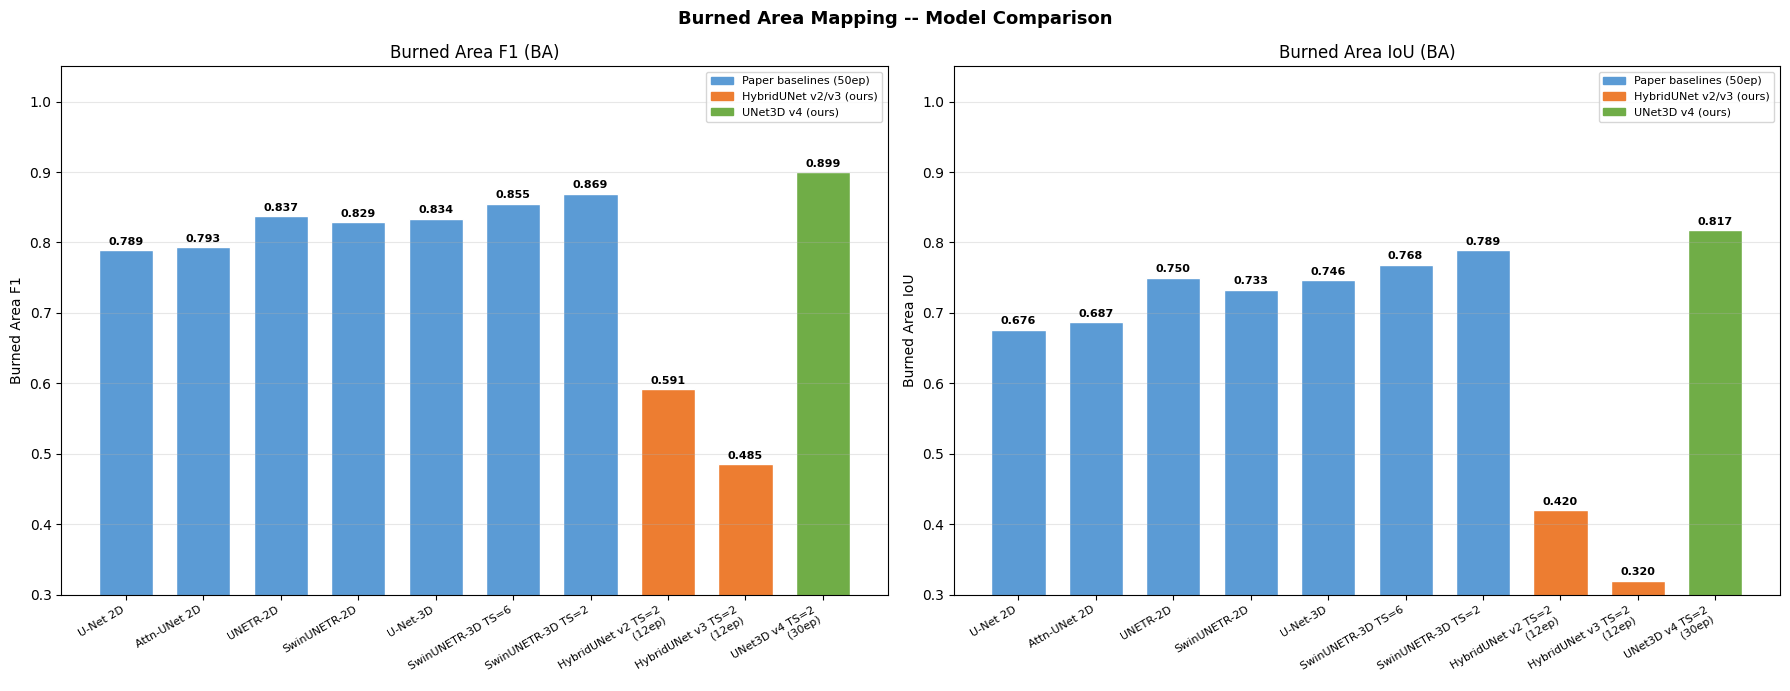

Saved /kaggle/working/benchmark_comparison_v4.png


In [12]:
paper_models = [
    ('U-Net 2D',          0.789, 0.676),
    ('Attn-UNet 2D',      0.793, 0.687),
    ('UNETR-2D',          0.837, 0.750),
    ('SwinUNETR-2D',      0.829, 0.733),
    ('U-Net-3D',          0.834, 0.746),
    ('SwinUNETR-3D TS=6', 0.855, 0.768),
    ('SwinUNETR-3D TS=2', 0.869, 0.789),
]
our_models = [
    ('HybridUNet v2 TS=2\n(12ep)', 0.5914, 0.4199),
    ('HybridUNet v3 TS=2\n(12ep)', 0.4850, 0.3200),
    (f'UNet3D v4 TS=2\n(30ep)',    overall_f1, overall_iou),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, metric_idx, ylabel, title in [
    (axes[0], 1, 'Burned Area F1',  'Burned Area F1 (BA)'),
    (axes[1], 2, 'Burned Area IoU', 'Burned Area IoU (BA)'),
]:
    all_names  = [m[0] for m in paper_models] + [m[0] for m in our_models]
    all_vals   = [m[metric_idx] for m in paper_models] + [m[metric_idx] for m in our_models]
    all_colors = ['#5B9BD5'] * len(paper_models) + \
                 ['#ED7D31', '#ED7D31', '#70AD47']

    bars = ax.bar(range(len(all_names)), all_vals,
                  color=all_colors, edgecolor='white', width=0.7)
    for bar, val in zip(bars, all_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(range(len(all_names)))
    ax.set_xticklabels(all_names, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0.3, 1.05)
    ax.grid(True, alpha=0.3, axis='y')

    blue_p  = mpatches.Patch(color='#5B9BD5', label='Paper baselines (50ep)')
    orange_p = mpatches.Patch(color='#ED7D31', label='HybridUNet v2/v3 (ours)')
    green_p = mpatches.Patch(color='#70AD47', label='UNet3D v4 (ours)')
    ax.legend(handles=[blue_p, orange_p, green_p], fontsize=8)

plt.suptitle('Burned Area Mapping -- Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
bench_path = os.path.join(OUTPUT_DIR, 'benchmark_comparison_v4.png')
plt.savefig(bench_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {bench_path}')

## Training curves with test result

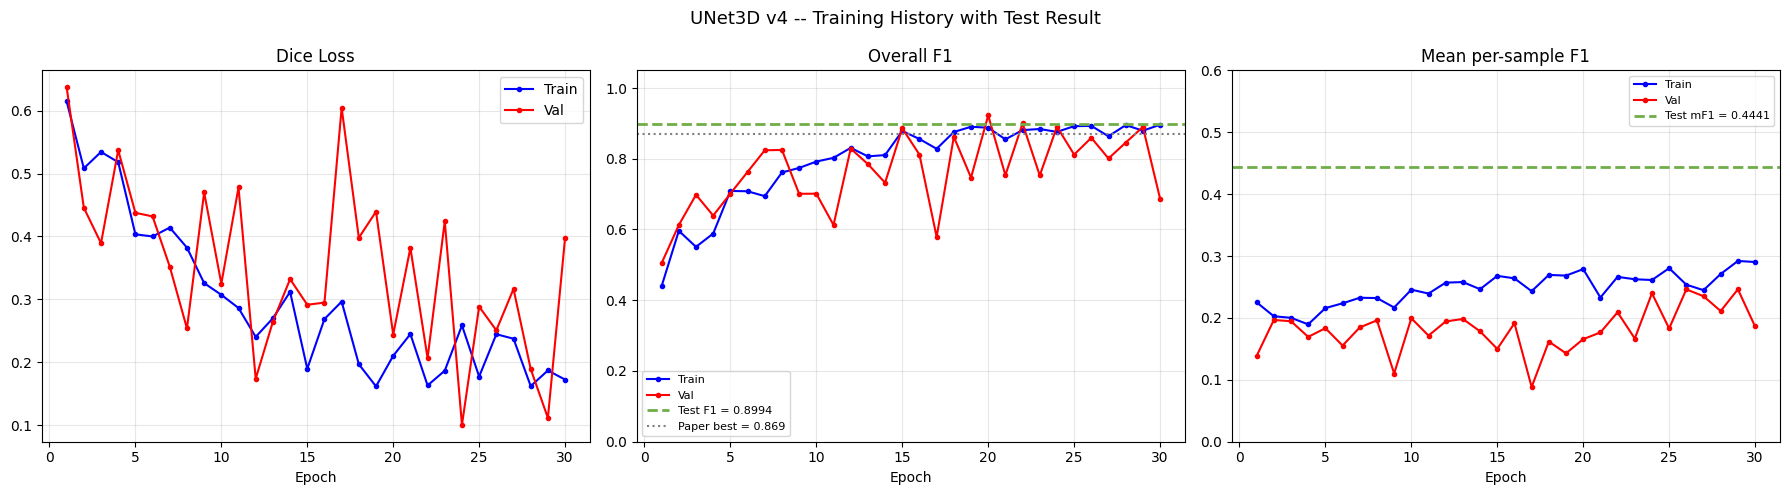

Saved /kaggle/working/training_curves_v4_final.png


In [13]:
if os.path.exists(HIST_PATH):
    with open(HIST_PATH) as f:
        h = json.load(f)

    epochs = range(1, len(h['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, h['train_loss'], 'b-o', markersize=3, label='Train')
    axes[0].plot(epochs, h['val_loss'],   'r-o', markersize=3, label='Val')
    axes[0].set_title('Dice Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, h['train_F1'], 'b-o', markersize=3, label='Train')
    axes[1].plot(epochs, h['val_F1'],   'r-o', markersize=3, label='Val')
    axes[1].axhline(overall_f1, color='#70AD47', lw=2, ls='--',
                    label=f'Test F1 = {overall_f1:.4f}')
    axes[1].axhline(0.869, color='gray', lw=1.5, ls=':',
                    label='Paper best = 0.869')
    axes[1].set_title('Overall F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, h['train_mF1'], 'b-o', markersize=3, label='Train')
    axes[2].plot(epochs, h['val_mF1'],   'r-o', markersize=3, label='Val')
    axes[2].axhline(mean_f1, color='#70AD47', lw=2, ls='--',
                    label=f'Test mF1 = {mean_f1:.4f}')
    axes[2].set_title('Mean per-sample F1')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylim(0, 0.6)
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.suptitle('UNet3D v4 -- Training History with Test Result', fontsize=13)
    plt.tight_layout()
    curve_path = os.path.join(OUTPUT_DIR, 'training_curves_v4_final.png')
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {curve_path}')
else:
    print(f'history_v4.json not found at {HIST_PATH} -- skipping training curves')

## Random visual predictions

6 randomly selected test fires. For each fire, one sample is shown:
RGB composite (I3/I2/I1), ground truth BA mask, and model prediction.

Plotting fires: ['US_2021_NM3323810847220210520', 'US_2021_AZ3345510938920210616', 'US_2021_NM3344410803520210514', 'US_2021_MT4714310953420211004', 'US_2021_CA3627811855020210815', 'US_2021_WA4856812048820210708']


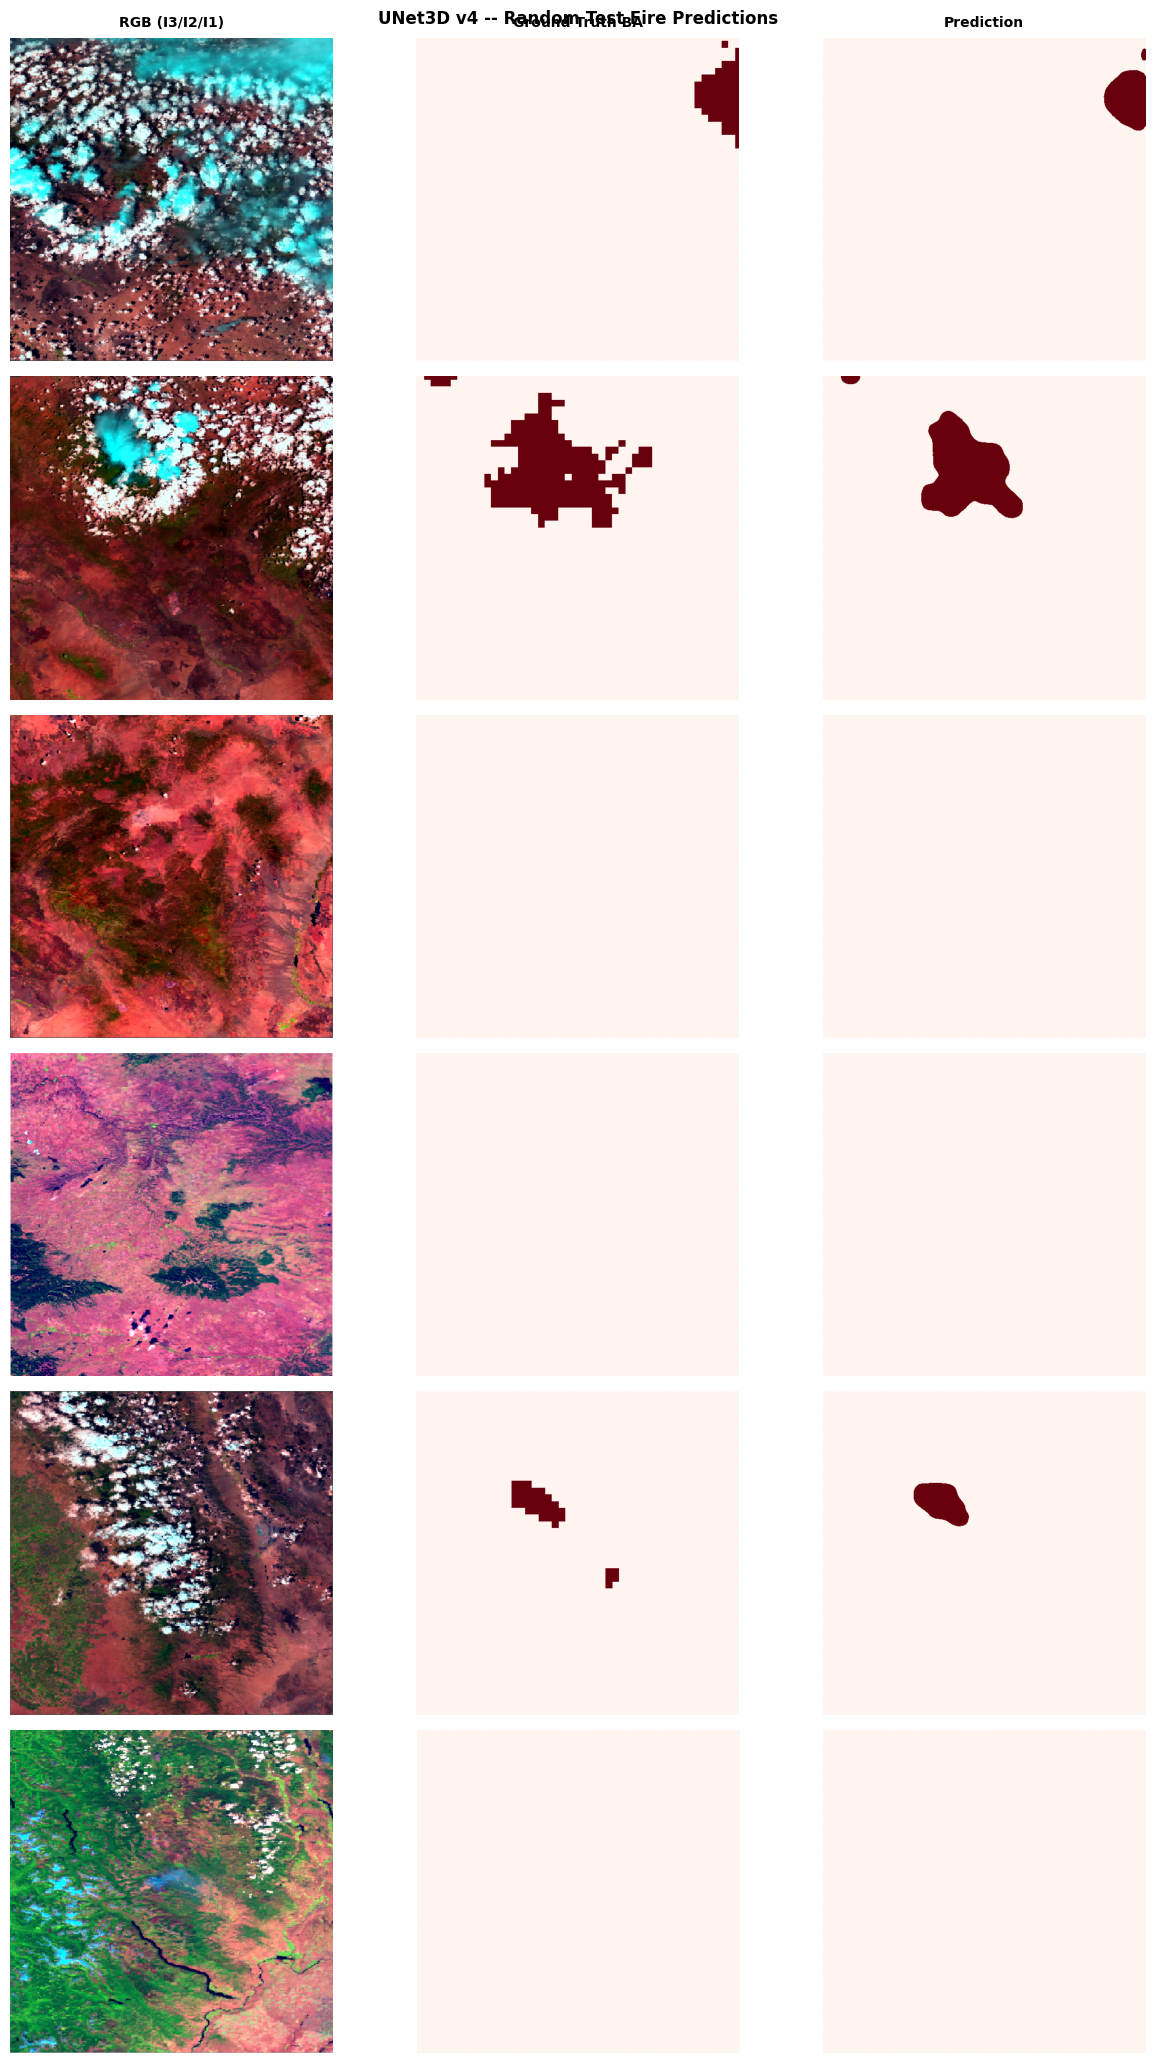

Saved /kaggle/working/visual_predictions_v4.png


In [14]:
def get_rgb(x_tensor):
    """Return displayable RGB from bands I3(2), I2(1), I1(0) of the last timestep."""
    # x_tensor: (C, T, H, W)
    arr = x_tensor.cpu().numpy()   # (C, T, H, W)
    # last timestep, bands I3=2, I2=1, I1=0
    r = arr[2, -1]   # I3 SWIR
    g = arr[1, -1]   # I2 NIR
    b = arr[0, -1]   # I1 Red
    rgb = np.stack([r, g, b], axis=-1)
    lo, hi = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-6), 0, 1)
    return rgb


# Build fire_id -> first sample index map
fid_to_idx = {}
for idx, s in enumerate(test_ds.samples):
    fid = os.path.basename(s['fire_dir'])
    if fid not in fid_to_idx:
        fid_to_idx[fid] = idx

# Random selection of 6 fires
random.seed(SEED + 99)
available = list(fid_to_idx.keys())
chosen    = random.sample(available, min(6, len(available)))
print(f'Plotting fires: {chosen}')

fig, axes = plt.subplots(len(chosen), 3, figsize=(13, len(chosen) * 3.5))
if len(chosen) == 1:
    axes = axes[None]

col_titles = ['RGB (I3/I2/I1)', 'Ground Truth BA', 'Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=8)

model.eval()
with torch.no_grad():
    for row, fid in enumerate(chosen):
        idx    = fid_to_idx[fid]
        x, y   = test_ds[idx]
        x_dev  = x.unsqueeze(0).to(device)

        xp, H_orig, W_orig = pad_to_multiple(x_dev)
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(xp)
        logits = logits[:, :, :H_orig, :W_orig]
        prob   = torch.softmax(logits.float(), dim=1)[:, 1]
        pred   = (prob > INFER_THRESHOLD).long().cpu().squeeze().numpy()
        lbl    = y.numpy()
        rgb    = get_rgb(x)

        fire_row = df_fire[df_fire['fire_id'] == fid]
        f1_val   = fire_row['F1'].values[0] if len(fire_row) > 0 else float('nan')

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_ylabel(f'{fid[-14:]}\nF1={f1_val:.3f}', fontsize=8)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(lbl,  cmap='Reds', vmin=0, vmax=1)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred, cmap='Reds', vmin=0, vmax=1)
        axes[row, 2].axis('off')

plt.suptitle('UNet3D v4 -- Random Test Fire Predictions', fontsize=12, fontweight='bold')
plt.tight_layout()
vis_path = os.path.join(OUTPUT_DIR, 'visual_predictions_v4.png')
plt.savefig(vis_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {vis_path}')

## Zip all outputs

In [15]:
output_files = [
    'test_results_v4.json',
    'per_fire_results_v4.csv',
    'model_analysis_v4.txt',
    'training_curves_v4_final.png',
    'f1_distribution_v4.png',
    'benchmark_comparison_v4.png',
    'visual_predictions_v4.png',
]

zip_path = os.path.join(OUTPUT_DIR, 'unet3d_v4_results.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in output_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, arcname=fname)
            size_kb = os.path.getsize(fpath) / 1024
            print(f'  added  {fname:<45} {size_kb:>7.1f} KB')
        else:
            print(f'  SKIP   {fname}  (not found)')

zip_size = os.path.getsize(zip_path) / 1024**2
print(f'\nZip created : {zip_path}  ({zip_size:.1f} MB)')

print('\nAll output files:')
print('=' * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.isfile(fpath): continue
    size  = os.path.getsize(fpath)
    unit  = 'KB' if size < 1024**2 else 'MB'
    val   = size/1024 if unit == 'KB' else size/1024**2
    print(f'  {fname:<50} {val:>7.1f} {unit}')

  added  test_results_v4.json                              4.5 KB
  added  per_fire_results_v4.csv                           1.5 KB
  added  model_analysis_v4.txt                             5.0 KB
  added  training_curves_v4_final.png                    172.4 KB
  added  f1_distribution_v4.png                          302.3 KB
  added  benchmark_comparison_v4.png                     126.0 KB
  added  visual_predictions_v4.png                      3368.5 KB

Zip created : /kaggle/working/unet3d_v4_results.zip  (3.8 MB)

All output files:
  benchmark_comparison_v4.png                          126.0 KB
  f1_distribution_v4.png                               302.3 KB
  model_analysis_v4.txt                                  5.0 KB
  per_fire_results_v4.csv                                1.5 KB
  test_results_v4.json                                   4.5 KB
  training_curves_v4_final.png                         172.4 KB
  unet3d_v4_results.zip                                  3.8 MB
  visual